# Linear Models

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
data_path = "./WineQT.csv"

In [4]:
df = pd.read_csv(data_path)

In [5]:
y = df["quality"]

In [6]:
X = df.drop("quality", axis=1)

Good practice is 80/20 split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Linear Regression

In [8]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
y_pred = model.predict(X_test)

array([5.42239406, 4.75039315, 5.29684786, 5.08885868, 6.09486333,
       6.61357779, 5.4017609 , 5.12073623, 5.80682335, 5.32701664,
       6.34740954, 6.36404342, 5.30874791, 6.20726473, 5.82424736,
       4.84564054, 5.6866377 , 5.69867218, 5.46145685, 6.40788444,
       6.03767614, 6.03147727, 5.20921387, 6.48042456, 5.62504152,
       5.15767898, 6.56630591, 5.96162446, 5.13243268, 5.55393556,
       6.22138034, 5.50621416, 6.61300256, 5.72900211, 5.57167536,
       5.30091294, 5.50270472, 6.03438174, 6.9574108 , 6.57721823,
       6.44071484, 5.36204407, 7.11515613, 5.3357927 , 5.02045693,
       5.1019234 , 5.66565116, 5.86060262, 4.62611376, 5.64639624,
       6.43111192, 5.3070245 , 5.66220358, 5.90248884, 5.7764028 ,
       6.40204632, 5.49239433, 5.66938259, 6.05514973, 5.22988268,
       5.53032108, 5.94808156, 5.64622439, 6.32047068, 6.13819951,
       5.42307061, 6.88637688, 5.23198061, 4.89240584, 5.94146638,
       5.72706586, 5.36371717, 5.87330383, 5.930108  , 5.20816

In [19]:
y_round = y_pred.round()

In [10]:
print(f"Training set score: {model.score(X_train, y_train):.2f}")
print(f"Test set score: {model.score(X_test, y_test):.2f}")

Training set score: 0.38
Test set score: 0.31


Both scores are low -> Underfitting

In [20]:
print(f"Test set score with round values: {r2_score(y_test, y_round):.2f}")

Test set score (R²) with round values: 0.14


We can visualize the coefficients of the model.

Since it is a simple regression, interpretation of the coefficients is streigthforward: positive values increase quality, negative values decrease quality

In [11]:
coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
})

print(coefficients.sort_values("coefficient", ascending=False))

                 feature  coefficient
9              sulphates     0.953929
10               alcohol     0.271614
0          fixed acidity     0.044828
3         residual sugar     0.004647
5    free sulfur dioxide     0.002789
11                    Id    -0.000072
6   total sulfur dioxide    -0.002587
8                     pH    -0.284072
2            citric acid    -0.320227
1       volatile acidity    -1.326510
4              chlorides    -1.836925
7                density   -32.767833


Perfect predictions would lie on the diagonal line.

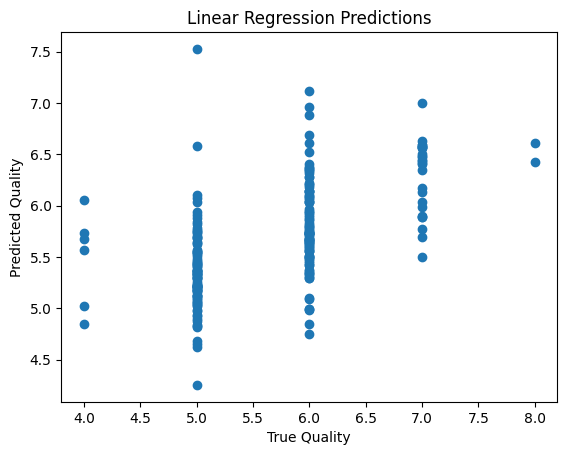

In [12]:
plt.scatter(y_test, y_pred)
plt.xlabel("True Quality")
plt.ylabel("Predicted Quality")
plt.title("Linear Regression Predictions")
plt.show()

logistic regression requires a categorical target, while the wine dataset has an ordinal score (3–8)

You can use __Multiclass Logistic Regression__ But performance is usually worse because:

- classes are imbalanced

- dataset small

Because quality is ordered, the theoretically best model is __ordinal regression__

Example libraries:

- statsmodels

- mord

But in practice __tree models__ outperform it.

## Ridge Regression

In [21]:
from sklearn.linear_model import Ridge

In [22]:
ridge = Ridge()

In [23]:
ridge.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [26]:
print(f"Training set score: {ridge.score(X_train, y_train):.2f}")
print(f"Test set score: {ridge.score(X_test, y_test):.2f}")

Training set score (R²): 0.38
Test set score (R²): 0.32


In [27]:
ridge.coef_

array([ 2.05895817e-02, -1.34160249e+00, -3.23761688e-01, -1.15537763e-02,
       -1.08531966e+00,  3.05863238e-03, -2.59041492e-03, -1.95523309e-02,
       -3.54424057e-01,  7.85204103e-01,  3.10982515e-01, -6.72337181e-05])

## Lasso Regression

In [28]:
from sklearn.linear_model import Lasso

In [29]:
lasso = Lasso()

In [30]:
lasso.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [36]:
print(f"Training set score: {lasso.score(X_train, y_train):.2f}")
print(f"Test set score: {lasso.score(X_test, y_test):.2f}")
print(f"Number of features used: {np.sum(lasso.coef_ != 0)}")

Training set score (R²): 0.03
Test set score (R²): 0.05
Number of features used: 2


In [33]:
lasso1 = Lasso(alpha=0.01, max_iter=100000)

In [34]:
lasso1.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",100000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [37]:
print(f"Training set score: {lasso1.score(X_train, y_train):.2f}")
print(f"Test set score: {lasso1.score(X_test, y_test):.2f}")
print(f"Number of features used: {np.sum(lasso1.coef_ != 0)}")

Training set score (R²): 0.36
Test set score (R²): 0.34
Number of features used: 8
